CAGR: 60.04 %


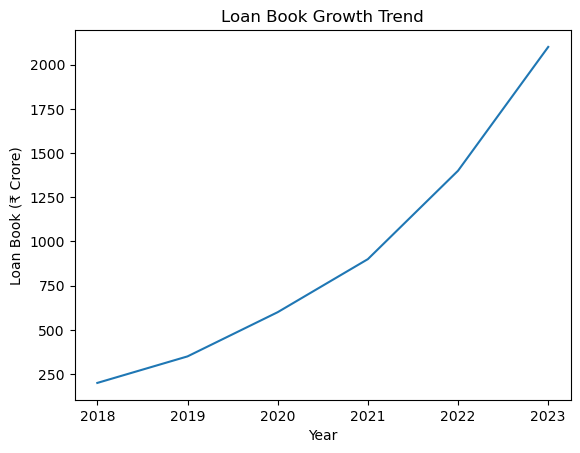

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Loan Book Data
growth_data = {
    "Year": [2018, 2019, 2020, 2021, 2022, 2023],
    "Loan_Book": [200, 350, 600, 900, 1400, 2100]
}

df_growth = pd.DataFrame(growth_data)

# CAGR
begin = df_growth["Loan_Book"].iloc[0]
end = df_growth["Loan_Book"].iloc[-1]
years = len(df_growth) - 1

cagr = (end / begin) ** (1/years) - 1
print("CAGR:", round(cagr*100,2), "%")

# Growth Graph
plt.plot(df_growth["Year"], df_growth["Loan_Book"])
plt.title("Loan Book Growth Trend")
plt.xlabel("Year")
plt.ylabel("Loan Book (₹ Crore)")
plt.show()

Default Rate: 28.0 %


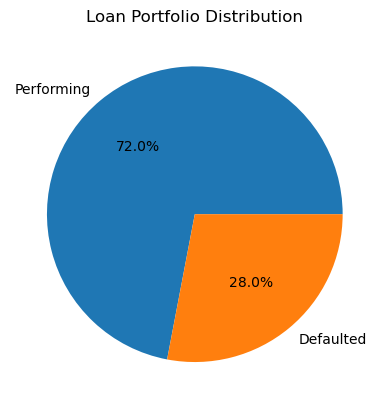

In [5]:
loan_data = pd.DataFrame({
    "Default_Flag": [0]*72 + [1]*28
})

default_rate = loan_data["Default_Flag"].mean()
print("Default Rate:", round(default_rate*100,2), "%")

# Pie Chart
counts = loan_data["Default_Flag"].value_counts()
plt.pie(counts, labels=["Performing","Defaulted"], autopct="%1.1f%%")
plt.title("Loan Portfolio Distribution")
plt.show()

                    transaction_volume  refund_rate  loan_amount  default_flag
transaction_volume            1.000000     0.134254     0.021704     -0.351059
refund_rate                   0.134254     1.000000     0.152158      0.581718
loan_amount                   0.021704     0.152158     1.000000      0.041416
default_flag                 -0.351059     0.581718     0.041416      1.000000


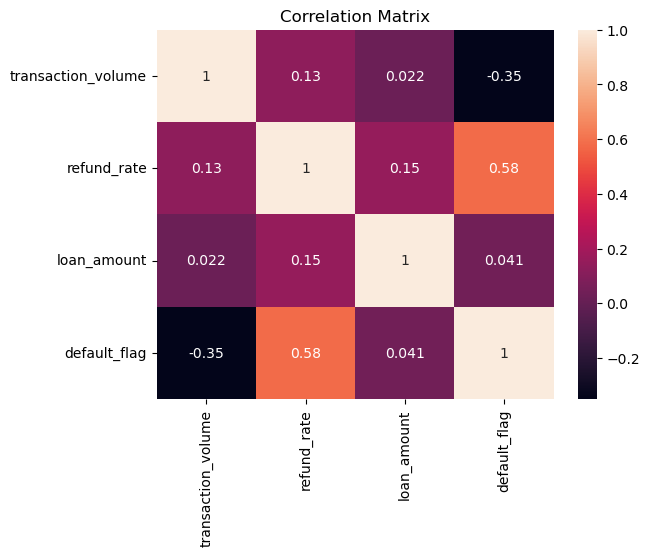

In [6]:
import seaborn as sns

np.random.seed(42)

data = pd.DataFrame({
    "transaction_volume": np.random.randint(5000,30000,100),
    "refund_rate": np.random.uniform(0.01,0.10,100),
    "loan_amount": np.random.randint(20000,150000,100)
})

data["default_flag"] = np.where(
    (data["refund_rate"]>0.06) |
    (data["transaction_volume"]<10000),
    1,0
)

corr = data.corr()
print(corr)

sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.show()

ROC-AUC: 0.64


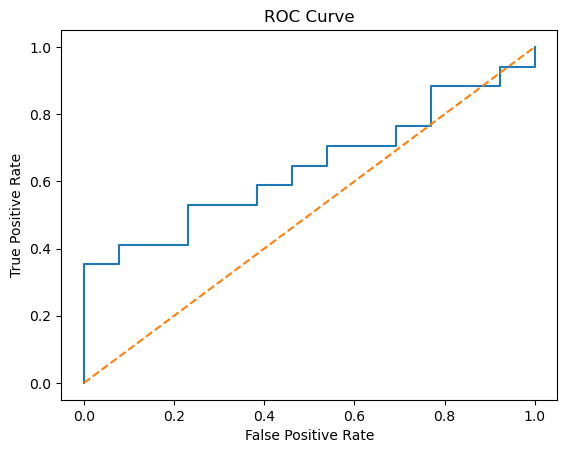

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve

X = data[['transaction_volume','refund_rate','loan_amount']]
y = data['default_flag']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3)

model = LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)

y_prob = model.predict_proba(X_test)[:,1]
roc_auc = roc_auc_score(y_test,y_prob)

print("ROC-AUC:", round(roc_auc,2))

fpr, tpr, _ = roc_curve(y_test,y_prob)
plt.plot(fpr,tpr)
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()